In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, recall_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =====================================================================
# 1. LOAD DATASET
# =====================================================================
# Pastikan kedua file CSV berada di direktori/folder yang sama dengan script ini
df = pd.read_csv('alzheimers_disease_data.csv')    # Data Kaggle sebagai fondasi
df_hermina = pd.read_csv('alzheimers_hermina.csv')  # Data Hermina khusus untuk Evaluasi Akhir

In [2]:
# =====================================================================
# 2. SELEKSI FITUR SECARA MANUAL
# =====================================================================
# Kita tentukan 22 fitur klinis dan gaya hidup yang krusial
manual_features = [
    'Age', 'Gender', 'BMI', 'Smoking', 'AlcoholConsumption', 
    'PhysicalActivity', 'DietQuality', 'SleepQuality', 
    'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 
    'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 
    'DiastolicBP', 'CholesterolTotal', 'MMSE', 'FunctionalAssessment', 
    'MemoryComplaints', 'BehavioralProblems', 'ADL'
]

target = 'Diagnosis'

# Memisahkan fitur dan target untuk basis data Kaggle
X = df[manual_features]
y = df[target]

print(f"Model akan dilatih menggunakan {len(manual_features)} fitur.")

Model akan dilatih menggunakan 22 fitur.


In [3]:
# =====================================================================
# 3. MEMBAGI DATA (TRAIN, TEST, EVALUATE)
# =====================================================================
# A. Bagi Data Kaggle menjadi 80% Train dan 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# B. Siapkan Data Hermina khusus untuk Tahap Evaluate Akhir (Validasi Eksternal)
X_evaluate_hermina = df_hermina[manual_features]
y_evaluate_hermina = df_hermina[target]

print(f"Jumlah Data Training (Kaggle)  : {X_train.shape[0]} baris")
print(f"Jumlah Data Testing (Kaggle)   : {X_test.shape[0]} baris")
print(f"Jumlah Data Evaluate (Hermina) : {X_evaluate_hermina.shape[0]} baris\n")

Jumlah Data Training (Kaggle)  : 1719 baris
Jumlah Data Testing (Kaggle)   : 430 baris
Jumlah Data Evaluate (Hermina) : 100 baris



In [4]:
# =====================================================================
# 4. PENGATURAN XGBOOST & HYPERPARAMETER TUNING (RECALL TINGGI)
# =====================================================================
# Menghitung rasio kelas negatif dibanding positif untuk menangani data imbalance
ratio = float(np.sum(y == 0)) / np.sum(y == 1)

# Inisialisasi model dasar
model_xgb = xgb.XGBClassifier(
    use_label_encoder=False, 
    eval_metric='logloss', 
    random_state=42
)

# Parameter yang diperluas untuk mencari kombinasi TERBAIK & PALING OPTIMAL
param_grid = {
    'max_depth': [3, 4, 5, 6],           
    'learning_rate': [0.01, 0.05, 0.1, 0.2], 
    'n_estimators': [100, 150, 200, 250],  
    'scale_pos_weight': [1, ratio],      
    'subsample': [0.7, 0.8, 1.0],        
    'colsample_bytree': [0.7, 0.8, 1.0], 
    'gamma': [0, 0.1, 0.2]               
}

print("Memulai pencarian hyperparameter terbaik secara mendalam...")

# Menjalankan GridSearchCV dengan fokus metrik 'recall' demi akurasi medis
grid_search = GridSearchCV(
    estimator=model_xgb, 
    param_grid=param_grid, 
    scoring='recall', 
    cv=5,            # 5-Fold Cross Validation
    n_jobs=-1,       # Memaksimalkan semua core CPU komputer kamu agar proses cepat
    verbose=1        # Menampilkan indikator progres jalannya tuning
)

print("Sedang melatih model dengan kombinasi parameter baru, mohon tunggu...")
grid_search.fit(X_train, y_train)

Memulai pencarian hyperparameter terbaik secara mendalam...
Sedang melatih model dengan kombinasi parameter baru, mohon tunggu...
Fitting 5 folds for each of 3456 candidates, totalling 17280 fits


C:\Users\Rafi Yandra M F\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:10:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'



     ANALISIS OVERFITTING & UNDERFITTING      
Akurasi Data Training (Kaggle) : 0.9308
Akurasi Data Testing (Kaggle)  : 0.9163
----------------------------------------------
Recall Data Training (Kaggle)   : 0.9359
Recall Data Testing (Kaggle)    : 0.9211

   PERFORMA MODEL PADA DATA EVALUATE (HERMINA) 
Akurasi Data Hermina : 0.9400
Recall Data Hermina   : 0.9444

--- LAPORAN KLASIFIKASI LENGKAP (DATA HERMINA) ---
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        64
           1       0.89      0.94      0.92        36

    accuracy                           0.94       100
   macro avg       0.93      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100


Menampilkan grafik Confusion Matrix untuk data Hermina...


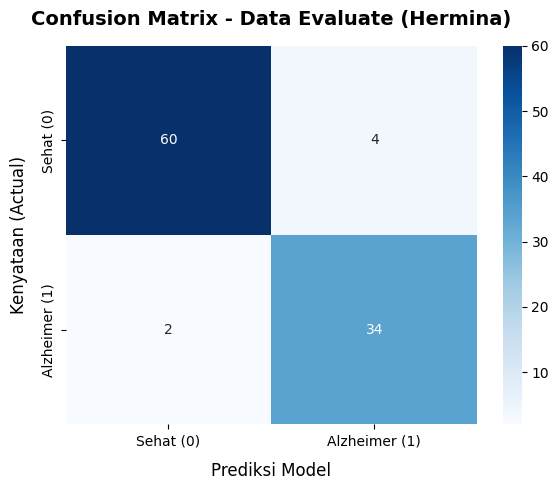

In [6]:
# =====================================================================
# 5. HASIL AKHIR & ANALISIS EVALUASI DAN CONFUSION MATRIX
# =====================================================================

# Mengambil model dengan parameter terbaik hasil tuning
best_model = grid_search.best_estimator_

# Prediksi untuk memeriksa Overfitting / Underfitting
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Prediksi eksternal khusus untuk Data Evaluate (Hermina)
y_hermina_pred = best_model.predict(X_evaluate_hermina)

# --- A. OUTPUT TEKS EVALUASI ---
print("\n==============================================")
print("     ANALISIS OVERFITTING & UNDERFITTING      ")
print("==============================================")
print(f"Akurasi Data Training (Kaggle) : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Akurasi Data Testing (Kaggle)  : {accuracy_score(y_test, y_test_pred):.4f}")
print("-" * 46)
print(f"Recall Data Training (Kaggle)   : {recall_score(y_train, y_train_pred):.4f}")
print(f"Recall Data Testing (Kaggle)    : {recall_score(y_test, y_test_pred):.4f}")
print("==============================================")

print("\n==============================================")
print("   PERFORMA MODEL PADA DATA EVALUATE (HERMINA) ")
print("==============================================")
print(f"Akurasi Data Hermina : {accuracy_score(y_evaluate_hermina, y_hermina_pred):.4f}")
print(f"Recall Data Hermina   : {recall_score(y_evaluate_hermina, y_hermina_pred):.4f}")
print("==============================================")

print("\n--- LAPORAN KLASIFIKASI LENGKAP (DATA HERMINA) ---")
print(classification_report(y_evaluate_hermina, y_hermina_pred))

# --- B. VISUALISASI CONFUSION MATRIX ---
print("\nMenampilkan grafik Confusion Matrix untuk data Hermina...")

# 1. Hitung Confusion Matrix untuk Data Hermina
cm_hermina = confusion_matrix(y_evaluate_hermina, y_hermina_pred)

# 2. Membuat Grafik Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_hermina, 
    annot=True,          # Menampilkan angka di dalam kotak
    fmt='d',             # Format angka sebagai bilangan bulat (integer)
    cmap='Blues',        # Gradasi warna biru mendalam
    cbar=True,           # Menampilkan batang indikator intensitas warna
    xticklabels=['Sehat (0)', 'Alzheimer (1)'], # Label sumbu X (Prediksi)
    yticklabels=['Sehat (0)', 'Alzheimer (1)']  # Label sumbu Y (Kenyataan Aktual)
)

# 3. Mengatur Atribut Teks Gambar
plt.title('Confusion Matrix - Data Evaluate (Hermina)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Prediksi Model', fontsize=12, labelpad=10)
plt.ylabel('Kenyataan (Actual)', fontsize=12, labelpad=10)
plt.tight_layout()

# 4. Tampilkan Grafik ke Layar
plt.show()

In [7]:
# =====================================================================
# 6. SIMPAN MODEL DAN STRUKTUR FITUR
# =====================================================================
# Menyimpan model beserta susunan fiturnya agar saat load di aplikasi tidak tertukar
model_data = {
    'model': best_model,
    'features': manual_features
}
joblib.dump(model_data, 'model_alzheimer_final.pkl')

print("\nModel dan daftar fitur berhasil disimpan ke 'model_alzheimer_final.pkl'")


Model dan daftar fitur berhasil disimpan ke 'model_alzheimer_final.pkl'
